In [1]:
import pandas as pd
import numpy as np
import uproot as ur
import histlite as hl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

# if you install ipympl for interactive plotting, you can activate by uncommenting line below
%matplotlib widget

In [2]:
# the range of TOF values is [-4096, 0]
daqcode=4096
nbands = 5
bands = [i+1 for i in range(nbands)]

def tof_daqcode_shift(arr, bands=bands): 
    '''
    some TOF values get offset by integer multiples of 4096, this brings them
    back into range of [-4096,0].
    
    input:
    arr - uncorrected TOF values
    output:
    arrcopy - corrected TOF values
    
    '''
    arrcopy = np.copy(arr)
    for i in bands: # doing 4 bands is fine for this data, can add more if necessary.
        arrcopy[np.logical_and(arrcopy < -i*daqcode, arrcopy >= -(i+1)*daqcode)] += i*daqcode
    return arrcopy

def tof_prompt_indices(arr):
    indices = np.logical_and(arr <= tof_edges[1], arr >= tof_edges[0]) # includes edge points
    return indices

def tof_late_indices(arr):
    indices = arr > tof_edges[1]
    return indices
    
def tof_early_indices(arr):
    indices = arr < tof_edges[0]
    return indices

In [17]:
# loop over run numbers for a given detector.


detectorindex = 0 # HPGE are indexed 0,2,4,6
save_pkl = True
save_root = False
print_info = True

# binning for the TOF histograms
binwidth = 20
tof_range = (-21000, binwidth) # so far, values seem to stop at -20511

beam_energy = '8.0 MeV'
run_no = [81,84,86,87]
run_type = ['100Mo', '100Mo', '100Mo', '56Fe']
# tof_edges = [-2400, -1300] # HPGE0, HPGE2
# tof_edges = [-2250, -1450] # HPGE0, HPGE2 avoiding bump near -2370
tof_edges = [-1960, -1300] # HPGE0, HPGE2 aggressive cut on main peak

# tof_edges = [-2900, -1800] # HPGE4, HPGE6
# tof_edges = [-2750, -1950] # HPGE4, HPGE6 avoiding bump near -2870


# beam_energy = '5.9 MeV'
# run_no = [69,70,71,73,74,78,79] # 78 is Fe, 79 is empty beam
# run_type = ['100Mo', '100Mo', '100Mo', '100Mo', '100Mo', '56Fe', 'empty']
# tof_edges = [-2200, -1100] # HPGE0 wide
# tof_edges = [-2300, -1200] # HPGE2 wide
# tof_edges = [-2800, -1700] # HPGE4 wide
# tof_edges = [-2700, -1600] # HPGE6 wide

# beam_energy = '4.3 MeV'
# run_no = [88,89] #,91]
# run_type = ['100Mo', '56Fe']#, 'empty']
# # tof_edges = [-2200, -1100] # HPGE0, HPGE2 wide
# tof_edges = [-2700, -1600] # HPGE4, HPGE6 wide




# the input file is a .pkl obtained from running preprocessing
inputdatadir = f'/home/joey/research/data/TUNL/test/pkl/raw/'

# the output file(s) are .pkl / .root time-of-flight processed
outputdatadir = f'/home/joey/research/data/TUNL/test/pkl/processed/'

# lists for time of flight histograms
htof_spectrum = []
htof_spectrum_corrected = []

for r,run in enumerate(run_no):
    
    
    inputfname = f'SSA{run}.pkl'
    outputfname = f'SSA{run}_HPGE{detectorindex}_{np.abs(tof_edges[0])}_{np.abs(tof_edges[1])}'
    preprocess_df = pd.read_pickle(inputdatadir+inputfname)
    
    TOF_df = pd.DataFrame()
    
    
        
    # for a given detector, NaN events are those that hit the other detectors, so drop them
    TOF_df['TOFraw'] = (preprocess_df[f'channel_time[{detectorindex}]']
                        - preprocess_df['trigger_time[0]']).dropna()
    
    tof_min = np.min(TOF_df['TOFraw'].to_numpy())
    tof_max = np.max(TOF_df['TOFraw'].to_numpy())
    np.arange(*tof_range, binwidth) 
    if print_info:
        print(f'file: {inputfname}')
        print(f'min TOF: {tof_min:.1f}, max TOF: {tof_max:.1f}')
        print(f'currently correcting values from {-daqcode} to {-(nbands+1)*daqcode}')
        print(f'adjust by changing nbands variable.')
    
    # these positive TOF events are present before / after correction of daq code glitch
    # for now we are dropping them from the analysis
        npos = TOF_df['TOFraw'][TOF_df['TOFraw'] > 0].size
        print(f'{TOF_df["TOFraw"].size} hits at the detector')
        print(f'there are {npos} events with positive TOF. These are being dropped from processing.' + '\n')
    
    # remove the positive TOF events
    unphysical_indices = TOF_df['TOFraw'][TOF_df['TOFraw']>0].index
    TOF_df.drop(unphysical_indices, inplace=True)
    
    # get indices left over after initial cuts (removing NaN and positive TOF), 
    # then create column with those amplitudes
    TOF_df['amplitude'] = preprocess_df[f'amplitude[{detectorindex}]'][TOF_df.index]
    # tofdf.amplitude.isnull().sum() # i beieve NaN removed when we cut on the time of flight, can double check here
    
    
    # correct daq code offset glitch
    TOF_df['TOF'] = tof_daqcode_shift(np.array(TOF_df['TOFraw']))
    
    
    # label good, early, late
    TOF_df['TOFlabel'] = 'good'
    TOF_df.loc[tof_early_indices(np.array(TOF_df['TOF'])), 'TOFlabel'] = 'early'
    TOF_df.loc[tof_late_indices(np.array(TOF_df['TOF'])), 'TOFlabel'] = 'late'
    
    if r == 0:
        # set all binning to the first histogram so they can be summed
        htof_spectrum.append(hl.hist(np.array(TOF_df['TOFraw']), 
                                     bins=np.arange(*tof_range, binwidth)))
        bins = htof_spectrum[0].bins
        htof_spectrum_corrected.append(hl.hist(TOF_df['TOF'], bins=bins))
    else:
        htof_spectrum.append(hl.hist(np.array(TOF_df['TOFraw']), bins=bins))
        htof_spectrum_corrected.append(hl.hist(TOF_df['TOF'], bins=bins))
        
    if save_pkl:
        print(f'saving file: {outputfname}.pkl to directory: {outputdatadir}'+'\n')
        TOF_df.to_pickle(outputdatadir+outputfname+'.pkl')
    
    if save_root:
        print(f'saving file: {outputfname}.root to directory: {outputdatadir}'+'\n')
        # save a rootfile with amplitudes + TOF values for early, good, late events
        rf = outputdatadir+outputfname+'.root'
        with ur.recreate(rf) as file: # file is a TDirectory object
            for tofval in ['early', 'late', 'good']:
                file.mktree(tofval, {'amplitude': TOF_df['amplitude'][TOF_df['TOFlabel']==tofval].to_numpy(),
                                     'TOF': TOF_df['TOF'][TOF_df['TOFlabel']==tofval].to_numpy()})
            file['TOF_info'] =  {'edges': [tof_edges[0], tof_edges[1]]}

file: SSA81.pkl
min TOF: -20511.9, max TOF: 20333.9
currently correcting values from -4096 to -24576
adjust by changing nbands variable.
3732664 hits at the detector
there are 12193 events with positive TOF. These are being dropped from processing.

saving file: SSA81_HPGE0_1960_1300 to directory: /home/joey/research/data/TUNL/test/pkl/processed/

file: SSA84.pkl
min TOF: -20507.7, max TOF: 20270.0
currently correcting values from -4096 to -24576
adjust by changing nbands variable.
4312223 hits at the detector
there are 14230 events with positive TOF. These are being dropped from processing.

saving file: SSA84_HPGE0_1960_1300 to directory: /home/joey/research/data/TUNL/test/pkl/processed/

file: SSA86.pkl
min TOF: -20511.6, max TOF: 20389.1
currently correcting values from -4096 to -24576
adjust by changing nbands variable.
4253574 hits at the detector
there are 14302 events with positive TOF. These are being dropped from processing.

saving file: SSA86_HPGE0_1960_1300 to directory: /

Text(0.5, 1.0, 'HPGE0: time-of-flight [-1960, -1300],  8.0 MeV')

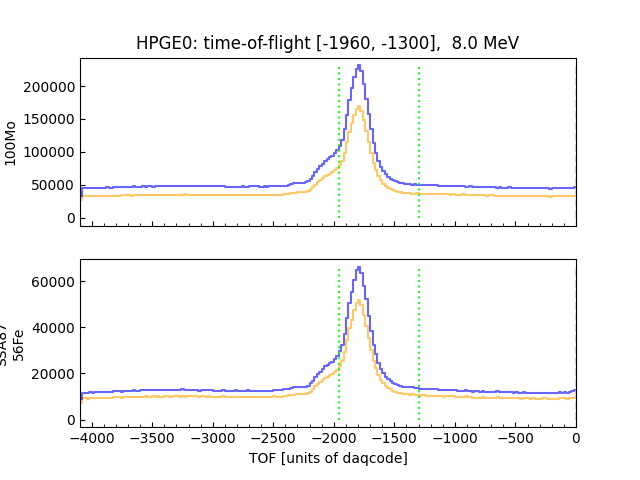

In [18]:
# plot the TOF processing result.

# just to keep code simple, put the datasets you want to be summed as the first entries
# in the list of run numbers 'run_no'. if this isn't the case, code wont work.

# sum_datasets = [69,70,71,73,74] # pass dataset numbers to be summed
sum_datasets= [81,84,86]
# sum_datasets = [] # pass empty list to plot all datasets separately

if sum_datasets :
    # calculate number of plots to make
    nplots = 1
    for ds in run_no:
        if ds not in sum_datasets:
            nplots+=1
            
    # sum the desired TOF histograms
    for i, sds in enumerate(sum_datasets):
        idx = int(np.where(np.array(run_no) == int(sds))[0][0])    
        if i == 0:
            htof_spectrum_sum = htof_spectrum[idx]
            htof_spectrum_corrected_sum = htof_spectrum_corrected[idx]
        else: 
            htof_spectrum_sum += htof_spectrum[idx]
            htof_spectrum_corrected_sum += htof_spectrum_corrected[idx]
            
else:
    nplots = len(run_no)
    
f,a = plt.subplots(nplots,1, sharex=True)

full_range = False # if true, plot the range of the values outside of [-4096, 0]
if full_range :
    xrange = (-(nbands+2)*daqcode, 0)
else :
    xrange = (-daqcode, 0)
    
for k in range(nplots):
    
    if k == 0:
        l1 = 'uncorrected'
        l2 = 'corrected'
        l3 = 'daqcode offset'
        l4 = f'prompt slice'
    else :
        l1 = None
        l2 = None
        l3 = None
        l4 = None
    
    if sum_datasets:
        if k==0:
            hl.plot1d(a[k], htof_spectrum_sum, label=l1, color='orange', alpha=0.6)
            hl.plot1d(a[k], htof_spectrum_corrected_sum, label=l2, color='blue', alpha=0.6)
            maxcounts = np.max(htof_spectrum_corrected_sum.values)
        else:
            hl.plot1d(a[k], htof_spectrum[len(sum_datasets)-1+k], label=l1, color='orange', alpha=0.6)
            hl.plot1d(a[k], htof_spectrum_corrected[len(sum_datasets)-1+k], label=l2, color='blue', alpha=0.6)
            maxcounts = np.max(htof_spectrum_corrected[len(sum_datasets)-1+k].values)
    else :
        hl.plot1d(a[k], htof_spectrum[k], label=l1, color='orange', alpha=0.6)
        hl.plot1d(a[k], htof_spectrum_corrected[k], label=l2, color='blue', alpha=0.6)
        maxcounts = np.max(htof_spectrum_corrected[k].values)
    
    for i, x in enumerate([-daqcode*j for j in range(nbands+2)]):
        if i==0:
            label=l3
        else:
            label=None
        
        a[k].plot([x,x],[0,maxcounts], color='pink', linestyle='--', alpha=0.9, label=label)
        
        # use this to plot the tof cut on all bands. when I check on 8MeV data, the peaks lined up as expected in each band.
        # for k,t in enumerate(tof_edges):
            
        #     if i==0 and k==0:
        #         label='prompt slice'
        #     else:
        #         label=None
                
        #     a.plot([t-i*daqcode,t-i*daqcode],[0,maxcounts], color='lime', linestyle=':', alpha=0.9, label=label)
    for j,t in enumerate(tof_edges):
            
            if j==0:
                label=l4
            else:
                label=None
                
            a[k].plot([t,t],[0,maxcounts], color='lime', linestyle=':', alpha=0.9, label=label)
    if sum_datasets and k==0:
        ylabel = f'SSA{str(sum_datasets)}' + '\n' + run_type[k]
    elif sum_datasets and k!=0:     
        ylabel = f'SSA{run_no[len(sum_datasets)-1+k]}' + '\n' + run_type[len(sum_datasets)-1+k]
    else :
        ylabel = f'SSA{run_no[k]}' + '\n' + run_type[k]
        
    a[k].set_ylabel(ylabel)
    
    # a.set_title('time-of-flight spectrum')
    a[k].set_xlim(*xrange)
    a[k].xaxis.set_minor_locator(ticker.MultipleLocator(100))
    a[k].xaxis.set_major_locator(ticker.MultipleLocator(500))
    a[k].tick_params(axis='x', which='both', direction='in')
    a[k].tick_params(axis='y', which='both', direction='in')



a[-1].set_xlabel('TOF [units of daqcode]')
a[0].set_title(f'HPGE{detectorindex}: time-of-flight [{tof_edges[0]}, {tof_edges[1]}],  {beam_energy}')
# f.legend(bbox_to_anchor=(.38, 0.3), loc='upper right', borderaxespad=0.)